# **Proyecto:**
## **Análisis Prescriptivo de Calidad del Aire**

## 1. Introducción
La contaminación del aire es uno de los principales problemas ambientales a nivel mundial.
Este proyecto tiene como objetivo consumir datos reales desde una API pública,
analizarlos y generar recomendaciones prescriptivas.

Fuente de datos: World Air Quality Index Project (WAQI).

API: https://aqicn.org/data-platform/token/


## 2. ¿Qué es el AQI?

El AQI (Air Quality Index) es un indicador numérico que resume el nivel de contaminación del aire.

Escala común:
- 0–50: Buena
- 51–100: Moderada
- 101–150: Dañina para grupos sensibles
- 151–200: Dañina
- 201–300: Muy dañina
- 300+: Peligrosa

El AQI se calcula con contaminantes como PM2.5, PM10, NO2, SO2, CO y O3.


## 3. Metodología

1. Conexión a API
2. Extracción de datos
3. Creación de DataFrame
4. Clasificación del AQI
5. Generación de recomendaciones
6. Visualización comparativa


In [1]:
!pip install requests pandas matplotlib seaborn --quiet

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 4. Conexión a la API

Usaremos el token demo (para proyectos formativos).
Se recomienda generar un token propio gratuito para uso académico serio.


In [3]:
# API_Propia : https://aqicn.org/data-platform/token/
#TOKEN = "demo"
TOKEN = "0ecf8b1be391472a46de9047db71be0fef77eeb5"

ciudades = ["medellin", "bogota", "cali", "mexico", "shanghai"]

datos = []

for ciudad in ciudades:
    url = f"https://api.waqi.info/feed/{ciudad}/?token={TOKEN}"
    response = requests.get(url)
    data = response.json()

    if data["status"] == "ok":
        aqi = data["data"]["aqi"]
        nombre = data["data"]["city"]["name"]
        fecha = data["data"]["time"]["s"]

        datos.append({
            "ciudad": nombre,
            "fecha": fecha,
            "AQI": aqi
        })


## 5. Creación del DataFrame

Transformamos la lista de diccionarios en una estructura tabular para análisis.


In [4]:
df = pd.DataFrame(datos)
df

,ciudad,fecha,AQI
0,"Aranjuez, Medellín, Colombia",2026-02-24 13:00:00,55
1,"San Cristobal, Bogota, Colombia",2026-02-24 14:00:00,107
2,"ERA-Obrero, Cali, Colombia",2021-06-07 18:00:00,31
3,"Merced, México, Mexico",2026-02-24 13:00:00,154
4,Shanghai (上海),2026-02-25 03:00:00,59


## 6. Clasificación del AQI

Convertimos el valor numérico en categorías interpretables.


In [5]:
def clasificar_aqi(valor):
    if valor <= 50:
        return "Buena"
    elif valor <= 100:
        return "Moderada"
    elif valor <= 150:
        return "Dañina grupos sensibles"
    elif valor <= 200:
        return "Dañina"
    else:
        return "Muy Dañina"

df["categoria"] = df["AQI"].apply(clasificar_aqi)
df

,ciudad,fecha,AQI,categoria
0,"Aranjuez, Medellín, Colombia",2026-02-24 13:00:00,55,Moderada
1,"San Cristobal, Bogota, Colombia",2026-02-24 14:00:00,107,Dañina grupos sensibles
2,"ERA-Obrero, Cali, Colombia",2021-06-07 18:00:00,31,Buena
3,"Merced, México, Mexico",2026-02-24 13:00:00,154,Dañina
4,Shanghai (上海),2026-02-25 03:00:00,59,Moderada


## 7. Modelo Prescriptivo

Se generan recomendaciones automáticas según el nivel de riesgo.


In [6]:
def recomendacion(categoria):
    if categoria == "Buena":
        return "Actividades normales"
    elif categoria == "Moderada":
        return "Reducir actividad prolongada"
    elif categoria == "Dañina grupos sensibles":
        return "Evitar ejercicio intenso"
    elif categoria == "Dañina":
        return "Usar mascarilla y limitar exposición"
    else:
        return "Activar alerta sanitaria"

df["recomendacion"] = df["categoria"].apply(recomendacion)
df

,ciudad,fecha,AQI,categoria,recomendacion
0,"Aranjuez, Medellín, Colombia",2026-02-24 13:00:00,55,Moderada,Reducir actividad prolongada
1,"San Cristobal, Bogota, Colombia",2026-02-24 14:00:00,107,Dañina grupos sensibles,Evitar ejercicio intenso
2,"ERA-Obrero, Cali, Colombia",2021-06-07 18:00:00,31,Buena,Actividades normales
3,"Merced, México, Mexico",2026-02-24 13:00:00,154,Dañina,Usar mascarilla y limitar exposición
4,Shanghai (上海),2026-02-25 03:00:00,59,Moderada,Reducir actividad prolongada


## 8. Visualización Comparativa

Comparación de ciudades según nivel actual de contaminación.


/tmp/ipython-input-1209677839.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="ciudad", y="AQI", data=df, palette = "pastel")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 28023 (\N{CJK UNIFIED IDEOGRAPH-6D77}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


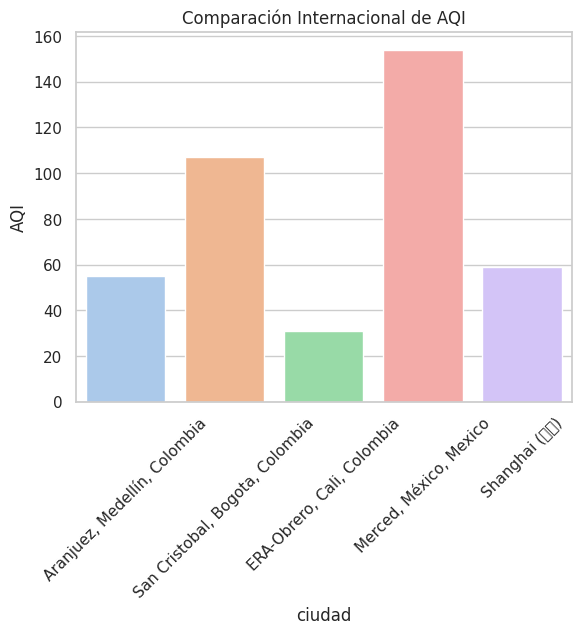

In [7]:
plt.figure()
sns.barplot(x="ciudad", y="AQI", data=df, palette = "pastel")
plt.xticks(rotation=45)
plt.title("Comparación Internacional de AQI")
plt.show()

## 9. Conclusiones

Este proyecto demuestra cómo:
- Consumir datos desde API
- Transformarlos en DataFrame
- Interpretar el AQI
- Generar análisis descriptivo
- Aplicar lógica prescriptiva

Puede escalarse a:
- Sistema de alertas universitario
- Dashboard municipal
- Modelo predictivo de contaminación
